# Transfer and extend normative models

Welcome to this tutorial notebook that will go through the transfering and extending of existing models on new data. 

Transfer and extend are both useful for when you have only a small dataset to your disposal, but you still want to derive a well-calibrated model from that. To get this well-calibrated model we use a large reference model (that was already trained before) and transfer it or extend it to our small dataset. As a result, we derive a new model that is better than a model that would be trained solely on our small dataset. 

**For transfer**, the new model will only be able to handle data from the batches in the small dataset; a small model is derived from a large reference model. 

**For extend**, the new model will be able to handle data from batches in the reference training set, as well as the batches in the new small dataset; a larger reference model is derived from a large reference model.


## Imports

In [7]:
import warnings
import logging


import pandas as pd
import matplotlib.pyplot as plt
from pcntoolkit import (
    HBR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    load_fcon1000,
    NormalLikelihood,
    make_prior,
    plot_centiles_advanced,
)

import pcntoolkit.util.output
import seaborn as sns

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")

pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'
pcntoolkit.util.output.Output.set_show_messages(False)

## Load data

First we download a small example dataset from github.

In [8]:
# Download the dataset
norm_data: NormData = load_fcon1000()

# Select the white matter hypointensities feature
features_to_model = [
    "WM-hypointensities"
]
norm_data = norm_data.sel({"response_vars": features_to_model})

# Leave two sites out for doing transfer and extend later
transfer_sites = ["Milwaukee_b", "Oulu"]
transfer_data, fit_data = norm_data.batch_effects_split({"site": transfer_sites}, names=("transfer", "fit"))

# Split into train and test sets
train, test = fit_data.train_test_split()
transfer_train, transfer_test = transfer_data.train_test_split()

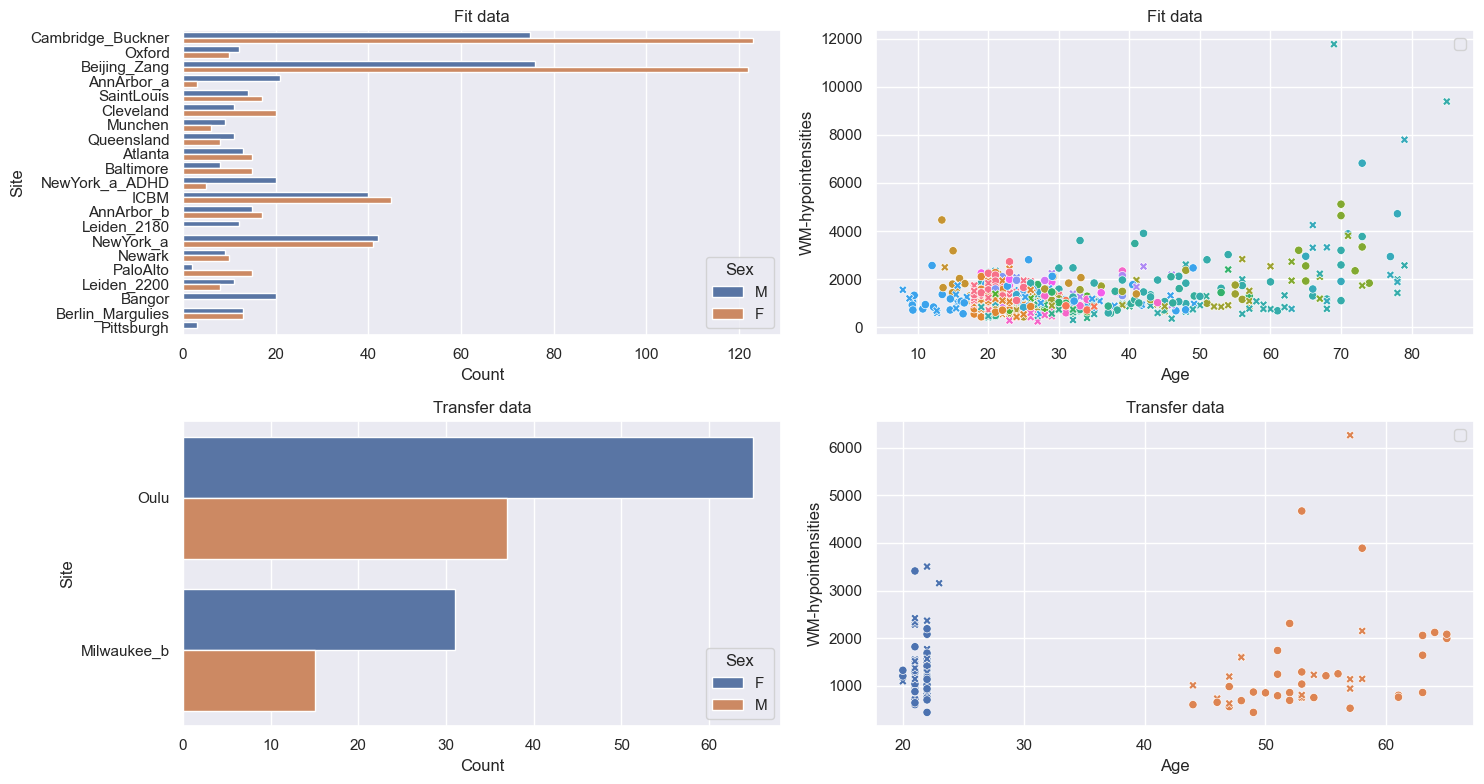

In [9]:
feature_to_plot = features_to_model[0]
datasets = {
    "Fit data": train.merge(test, name="fit"),
    "Transfer data": transfer_train.merge(
        transfer_test, name="transfer"
    ),
}

fig, axes = plt.subplots(
    2, 2, figsize=(15, 8)
)

for i, (name, data) in enumerate(
    datasets.items()
):
    df = data.to_dataframe()
    # Count plot
    sns.countplot(
        data=df,
        y=("batch_effects", "site"),
        hue=("batch_effects", "sex"),
        ax=axes[i, 0],
        orient="h",
    )
    axes[i, 0].legend(title="Sex")
    axes[i, 0].set_title(f"{name}")
    axes[i, 0].set_xlabel("Count")
    axes[i, 0].set_ylabel("Site")

    # Scatter plot
    sns.scatterplot(
        data=df,
        x=("X", "age"),
        y=("Y", feature_to_plot),
        hue=("batch_effects", "site"),
        style=("batch_effects", "sex"),
        ax=axes[i, 1],
    )
    axes[i, 1].legend([], [])
    axes[i, 1].set_title(f"{name}")
    axes[i, 1].set_xlabel("Age")
    axes[i, 1].set_ylabel(feature_to_plot)

plt.tight_layout()
plt.show()

## Normative model

### Create HBR model

In [10]:
mu = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
        sigma=make_prior(dist_name="Normal", dist_params=(0.0, 1.0), mapping="softplus", mapping_params=(0.0, 3.0)),
    ),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(0.0, 3.0),
)

likelihood = NormalLikelihood(mu, sigma)

template_hbr = HBR(
    name="template",
    cores=16,
    progressbar=False,
    draws=1500,
    tune=500,
    chains=4,
    nuts_sampler="nutpie",
    likelihood=likelihood,
)


### Create normative model

In [11]:
model = NormativeModel(
    template_regression_model=template_hbr,
    savemodel=True,
    evaluate_model=True,
    saveresults=True,
    saveplots=False,
    save_dir="resources/hbr/save_dir",
    inscaler="standardize",
    outscaler="standardize",
)

### Fit and plot normative model

c:\Users\kontsi\AppData\Local\anaconda3\envs\.ptk-dev\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


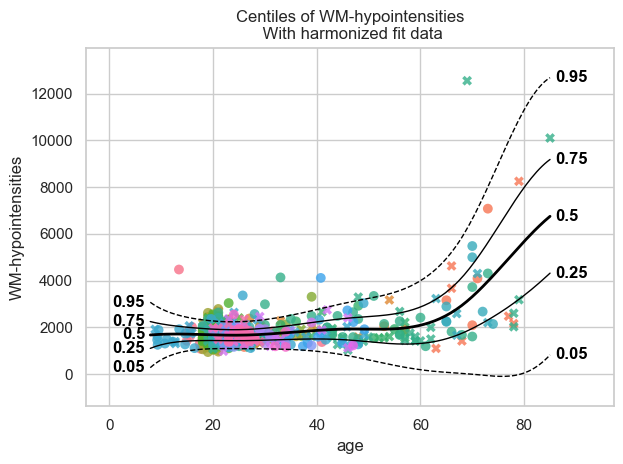

[<Figure size 640x480 with 1 Axes>]

In [12]:
test = model.fit_predict(train, test);

plot_centiles_advanced(
    model,
    scatter_data=train,
    batch_effects = 'all',
    show_legend = False
)

## Extending

Now that we have a fitted model, we can extend it using the data that we held out of the train set. This is from previously unseen sites.

And just to show why we prefer extend over just fitting a new model on the small dataset, we can show how bad such a model would be:

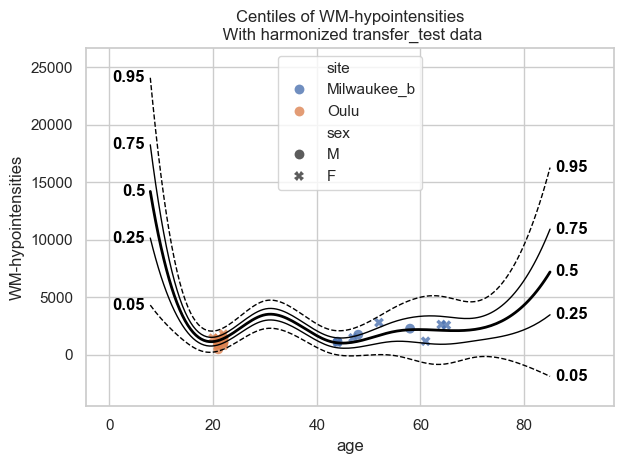

[<Figure size 640x480 with 1 Axes>]

In [13]:
small_model = NormativeModel(
    template_regression_model=template_hbr,
    savemodel=True,
    evaluate_model=True,
    saveresults=True,
    saveplots=False,
    save_dir="resources/hbr_transfer/save_dir_small",
    inscaler="standardize",
    outscaler="standardize",
)

small_model.fit_predict(transfer_train, transfer_test)

plot_centiles_advanced(
    small_model,
    scatter_data=transfer_test,
    batch_effects='all'
)

The interpolation between ages 22 and 45 is very bad, and that's because there was no train data there. This model will not perform well on new data. Now instead, let's extend the model we fitted before to our smaller dataset, and see how those centiles look:


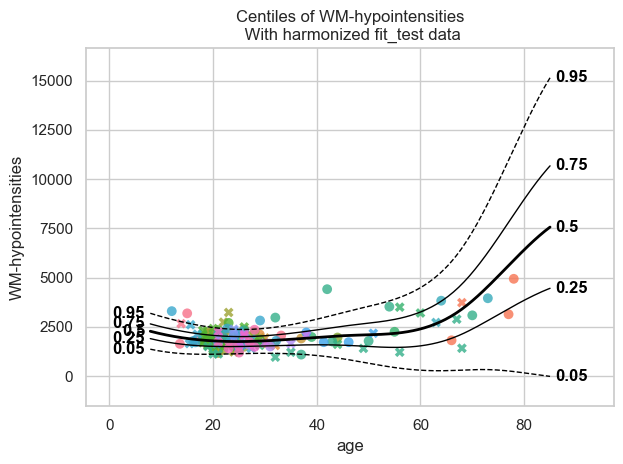

[<Figure size 640x480 with 1 Axes>]

In [14]:
extended_model = model.extend_predict(transfer_train, transfer_test);

plot_centiles_advanced(
    extended_model,
    scatter_data=test,
    batch_effects='all',
    show_legend = False
)

These centiles look much better in comparison to the 'small model' that we trained directly on the small dataset.  

## Transfering

Transfering looks very similar to extending, but the underlying mathematics is very different. Besides that, it leads to a smaller model instead of a bigger one; we can _not_ use a transfered model to make predictions on the original train data.  

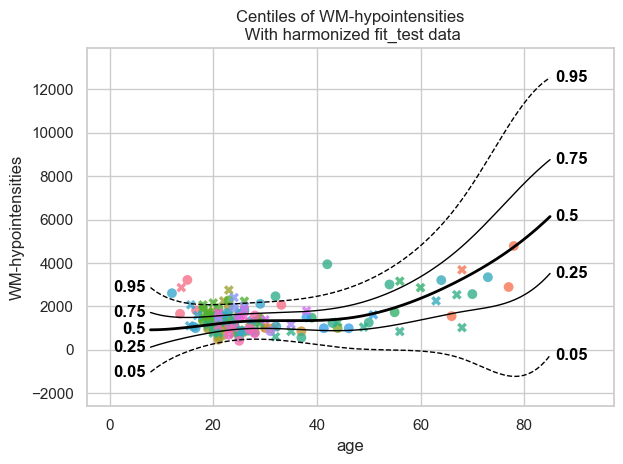

[<Figure size 640x480 with 1 Axes>]

In [15]:
transfered_model = model.transfer_predict(transfer_train, transfer_test);
plot_centiles_advanced(
    transfered_model,
    scatter_data=test,
    batch_effects='all',
    show_legend = False
)

Here we see that the transfered model is also much better than the 'small model' that we trained directly on the small dataset.  